# Contoso Customer NPS Analysis — Q4 2025

## Executive Summary

This notebook analyzes Q4 2025 customer survey responses (n=352) to understand NPS drivers and test whether mobile users truly have lower satisfaction. The clearest pattern is that satisfaction scores—especially checkout—and customer tenure move tightly with NPS. Mobile web is the outlier channel: it posts materially lower NPS and checkout satisfaction than app, desktop, or in-store, but that gap is partly explained by channel mix because all new customers are on mobile web and no loyal customers are. The stakeholder view should therefore separate mobile web from app and always show the mobile gap by tenure cohort.

## 1. Data Loading & Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configure visualization aesthetics
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Load data
df = pd.read_csv('../../research/data/customer-survey-2025.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nColumn names and types:')
print(df.dtypes)
print(f'\nFirst few rows:')
df.head()

Dataset shape: (352, 16)

Column names and types:
respondent_id               str
survey_date                 str
age                       int64
location                    str
customer_tenure           int64
membership_tier             str
purchase_frequency        int64
avg_order_value           int64
categories_purchased        str
channel_preference          str
nps_score                 int64
checkout_satisfaction     int64
search_satisfaction       int64
returns_satisfaction      int64
improvement_suggestion      str
favorite_feature            str
dtype: object

First few rows:


,respondent_id,survey_date,age,location,customer_tenure,membership_tier,purchase_frequency,avg_order_value,categories_purchased,channel_preference,nps_score,checkout_satisfaction,search_satisfaction,returns_satisfaction,improvement_suggestion,favorite_feature
0,a1b2c3d4-e5f6-4a7b-8c9d-0e1f2a3b4c5d,2025-10-03,34,CO,6,Gold,12,287,camping|hiking|apparel,desktop,9,5,4,5,NaN,gear reviews
1,b2c3d4e5-f6a7-4b8c-9d0e-1f2a3b4c5d6e,2025-10-05,28,CA,2,Bronze,5,142,hiking|apparel|footwear,mobile,7,3,4,4,mobile app crashes sometimes,easy returns
2,c3d4e5f6-a7b8-4c9d-0e1f-2a3b4c5d6e7f,2025-10-07,45,WA,8,Platinum,18,412,camping|climbing|water-sports|apparel,desktop,10,5,5,5,NaN,price matching
3,d4e5f6a7-b8c9-4d0e-1f2a-3b4c5d6e7f8a,2025-10-08,22,OR,1,NaN,3,89,hiking|apparel,mobile,6,2,3,4,faster checkout on mobile,trail finder
4,e5f6a7b8-c9d0-4e1f-2a3b-4c5d6e7f8a9b,2025-10-10,52,UT,9,Platinum,15,356,camping|hiking|climbing,app,9,4,5,5,NaN,expert advice chat


In [2]:
# Data exploration: summary statistics
print('Dataset Info:')
print(f'Total responses: {len(df)}')
print(f'Date range: {df["survey_date"].min()} to {df["survey_date"].max()}')
print(f'\nMissing values:')
print(df.isnull().sum())
print(f'\nBasic statistics for numeric columns:')
df.describe()

Dataset Info:
Total responses: 352
Date range: 2025-10-01 to 2025-12-31

Missing values:
respondent_id               0
survey_date                 0
age                         0
location                    0
customer_tenure             0
membership_tier            56
purchase_frequency          0
avg_order_value             0
categories_purchased        0
channel_preference          0
nps_score                   0
checkout_satisfaction       0
search_satisfaction         0
returns_satisfaction        0
improvement_suggestion    237
favorite_feature            0
dtype: int64

Basic statistics for numeric columns:


,age,customer_tenure,purchase_frequency,avg_order_value,nps_score,checkout_satisfaction,search_satisfaction,returns_satisfaction
count,352.000000,352.000000,352.000000,352.000000,352.000000,352.000000,352.000000,352.00000
mean,39.954545,4.781250,8.630682,227.642045,7.698864,3.812500,4.005682,4.18750
std,13.511130,3.141559,4.472132,109.656949,1.763898,1.088171,0.735716,0.69106
min,19.000000,0.000000,2.000000,67.000000,4.000000,2.000000,3.000000,3.00000
25%,28.000000,2.000000,5.000000,137.000000,6.000000,3.000000,3.000000,4.00000
50%,38.000000,5.000000,8.000000,213.000000,8.000000,4.000000,4.000000,4.00000
75%,51.000000,7.250000,12.250000,317.500000,9.000000,5.000000,5.000000,5.00000
max,71.000000,10.000000,18.000000,434.000000,10.000000,5.000000,5.000000,5.00000


In [3]:
# Data preparation: create derived columns for analysis
# Fill missing loyalty tier labels explicitly for cleaner stakeholder reporting
df['membership_tier'] = df['membership_tier'].fillna('None')

# NPS segments (industry standard)
df['nps_segment'] = pd.cut(
    df['nps_score'],
    bins=[-1, 6, 8, 10],
    labels=['Detractor (0-6)', 'Passive (7-8)', 'Promoter (9-10)']
)

# Tenure cohorts
df['tenure_cohort'] = pd.cut(
    df['customer_tenure'],
    bins=[-0.5, 0.5, 2.5, 5.5, 10.5],
    labels=['New (0y)', 'Growing (1-2y)', 'Established (3-5y)', 'Loyal (6y+)']
)

# Overall satisfaction (average across touchpoints)
satisfaction_cols = ['checkout_satisfaction', 'search_satisfaction', 'returns_satisfaction']
df['overall_satisfaction'] = df[satisfaction_cols].mean(axis=1)

# Mobile flags: separate mobile web from app for cleaner dashboard reporting
df['is_mobile_web'] = df['channel_preference'].eq('mobile')
df['is_mobile_surface'] = df['channel_preference'].isin(['mobile', 'app'])

print('Derived features created:')
print(f"\nMembership tiers:\n{df['membership_tier'].value_counts().sort_index()}")
print(f"\nNPS Segments:\n{df['nps_segment'].value_counts().sort_index()}")
print(f"\nTenure Cohorts:\n{df['tenure_cohort'].value_counts().sort_index()}")

Derived features created:

Membership tiers:
membership_tier
Bronze      43
Gold        91
None        56
Platinum    89
Silver      73
Name: count, dtype: int64

NPS Segments:
nps_segment
Detractor (0-6)     94
Passive (7-8)      117
Promoter (9-10)    141
Name: count, dtype: int64

Tenure Cohorts:
tenure_cohort
New (0y)               35
Growing (1-2y)         64
Established (3-5y)    104
Loyal (6y+)           149
Name: count, dtype: int64


## 2. NPS Segmentation Analysis

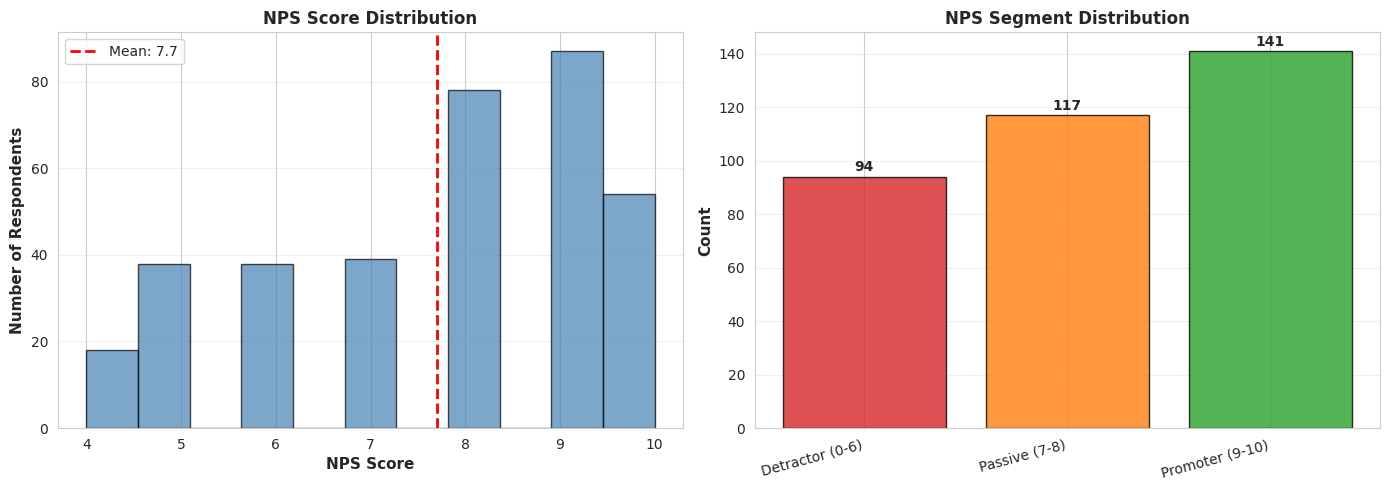

NPS Summary:
Mean NPS Score: 7.70
Median NPS Score: 8.0
Std Dev: 1.76

NPS® Metric:
Promoters: 141 (40.1%)
Detractors: 94 (26.7%)
NPS® Score: 13.4


In [4]:
# NPS distribution with summary statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution histogram
axes[0].hist(df['nps_score'], bins=11, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df['nps_score'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["nps_score"].mean():.1f}')
axes[0].set_xlabel('NPS Score', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Number of Respondents', fontsize=11, fontweight='bold')
axes[0].set_title('NPS Score Distribution', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# NPS segment breakdown
segment_counts = df['nps_segment'].value_counts().sort_index()
colors = ['#d62728', '#ff7f0e', '#2ca02c']
axes[1].bar(range(len(segment_counts)), segment_counts.values, color=colors, edgecolor='black', alpha=0.8)
axes[1].set_xticks(range(len(segment_counts)))
axes[1].set_xticklabels(segment_counts.index, rotation=15, ha='right')
axes[1].set_ylabel('Count', fontsize=11, fontweight='bold')
axes[1].set_title('NPS Segment Distribution', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(segment_counts.values):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary statistics
print('NPS Summary:')
print(f'Mean NPS Score: {df["nps_score"].mean():.2f}')
print(f'Median NPS Score: {df["nps_score"].median():.1f}')
print(f'Std Dev: {df["nps_score"].std():.2f}')
print(f'\nNPS® Metric:')
promoters = (df['nps_score'] >= 9).sum()
detractors = (df['nps_score'] <= 6).sum()
nps_metric = ((promoters - detractors) / len(df)) * 100
print(f'Promoters: {promoters} ({promoters/len(df)*100:.1f}%)')
print(f'Detractors: {detractors} ({detractors/len(df)*100:.1f}%)')
print(f'NPS® Score: {nps_metric:.1f}')

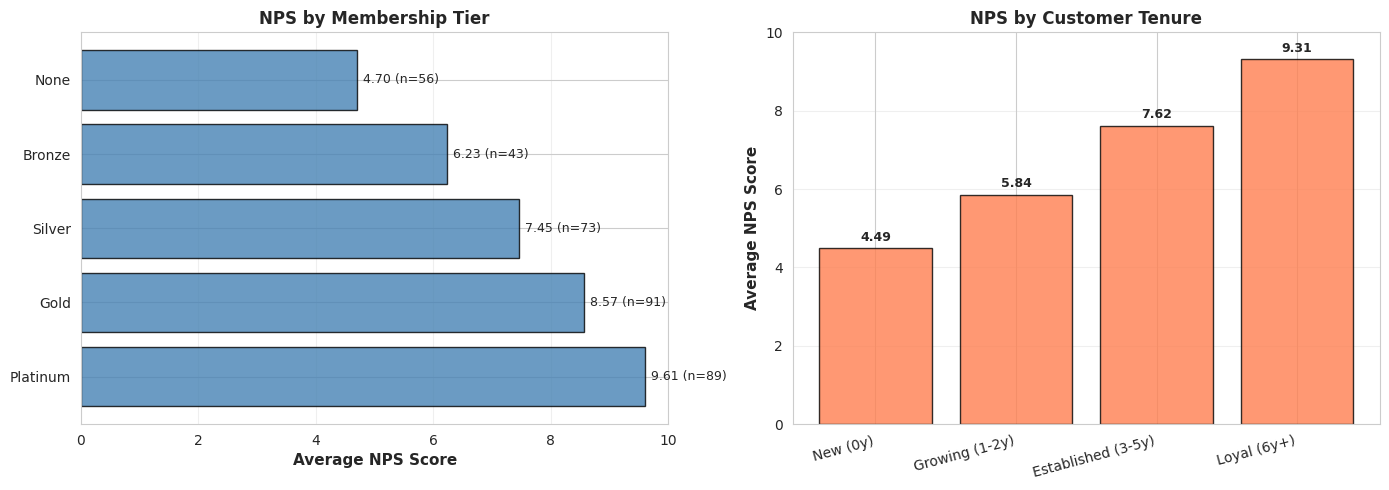

NPS by Membership Tier:
                     mean  count
membership_tier                 
Platinum         9.606742     89
Gold             8.571429     91
Silver           7.452055     73
Bronze           6.232558     43
None             4.696429     56

NPS by Tenure Cohort:
                        mean  count
tenure_cohort                      
New (0y)            4.485714     35
Growing (1-2y)      5.843750     64
Established (3-5y)  7.615385    104
Loyal (6y+)         9.308725    149


In [5]:
# NPS by membership tier and tenure
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# NPS by membership tier
tier_nps = df.groupby('membership_tier')['nps_score'].agg(['mean', 'count']).sort_values('mean', ascending=False)
axes[0].barh(tier_nps.index, tier_nps['mean'], color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Average NPS Score', fontsize=11, fontweight='bold')
axes[0].set_title('NPS by Membership Tier', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, 10)
axes[0].grid(axis='x', alpha=0.3)

# Add value labels
for i, (tier, row) in enumerate(tier_nps.iterrows()):
    axes[0].text(row['mean'] + 0.1, i, f"{row['mean']:.2f} (n={int(row['count'])})", va='center', fontsize=9)

# NPS by tenure cohort
tenure_nps = df.groupby('tenure_cohort')['nps_score'].agg(['mean', 'count']).sort_index()
axes[1].bar(range(len(tenure_nps)), tenure_nps['mean'].values, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_xticks(range(len(tenure_nps)))
axes[1].set_xticklabels(tenure_nps.index, rotation=15, ha='right')
axes[1].set_ylabel('Average NPS Score', fontsize=11, fontweight='bold')
axes[1].set_title('NPS by Customer Tenure', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 10)
axes[1].grid(axis='y', alpha=0.3)

# Add value labels
for i, (cohort, row) in enumerate(tenure_nps.iterrows()):
    axes[1].text(i, row['mean'] + 0.2, f"{row['mean']:.2f}", ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

print('NPS by Membership Tier:')
print(tier_nps)
print('\nNPS by Tenure Cohort:')
print(tenure_nps)

## 3. Mobile vs Desktop Channel Analysis

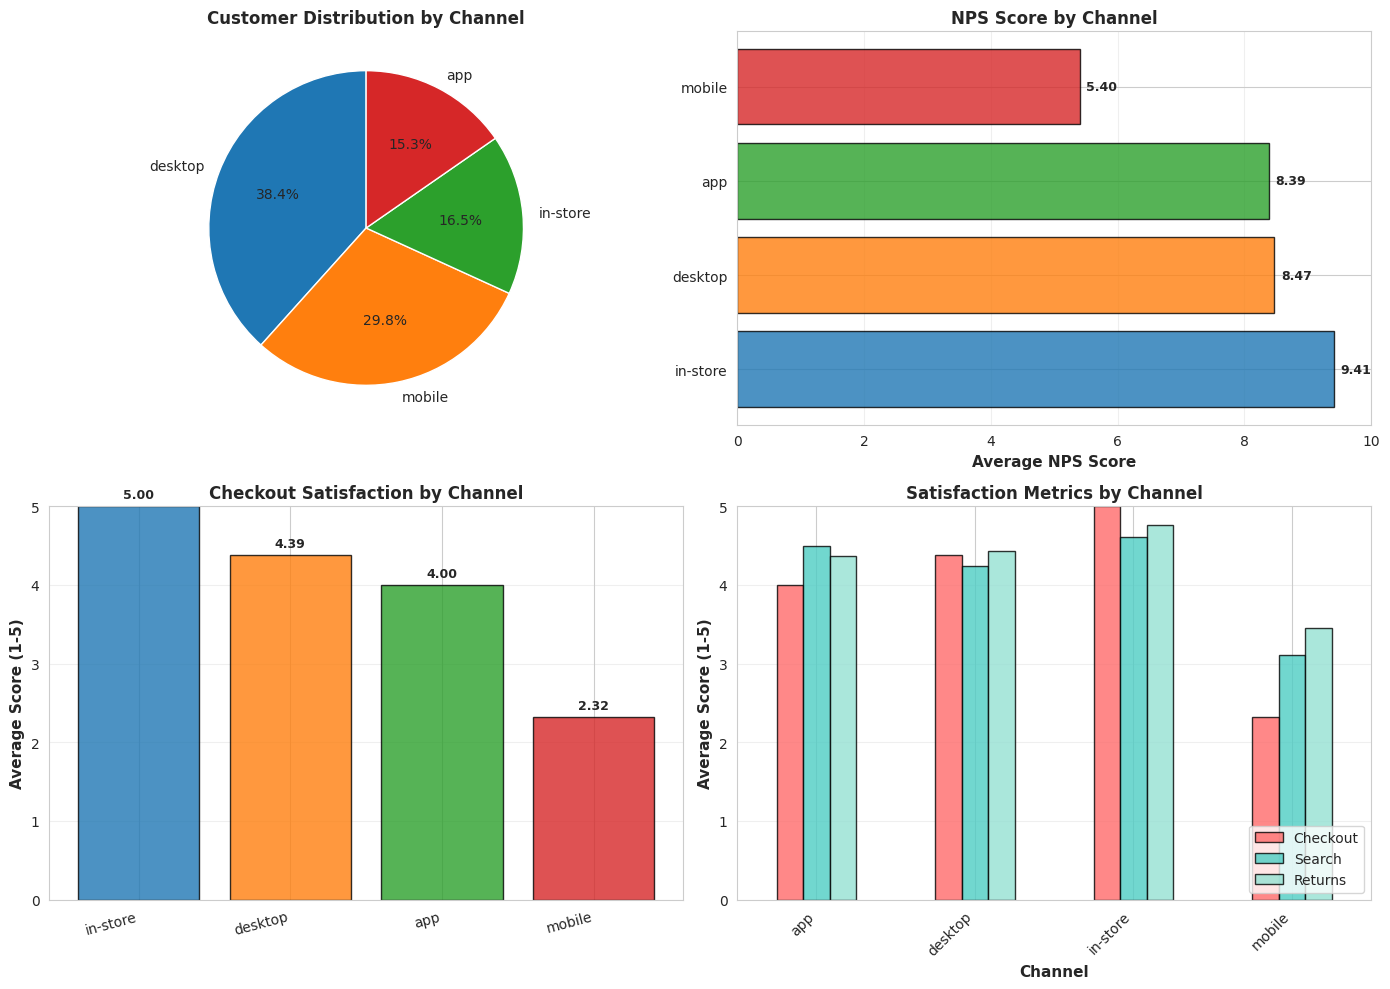

Channel Analysis Summary:

Channel Distribution:
channel_preference
desktop     135
mobile      105
in-store     58
app          54
Name: count, dtype: int64

NPS by Channel:
channel_preference
in-store    9.413793
desktop     8.474074
app         8.388889
mobile      5.400000
Name: nps_score, dtype: float64

Checkout Satisfaction by Channel:
channel_preference
in-store    5.000000
desktop     4.385185
app         4.000000
mobile      2.323810
Name: checkout_satisfaction, dtype: float64


In [6]:
# Channel distribution and satisfaction metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Channel distribution
channel_counts = df['channel_preference'].value_counts()
colors_channel = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
axes[0, 0].pie(channel_counts.values, labels=channel_counts.index, autopct='%1.1f%%', 
               colors=colors_channel, startangle=90)
axes[0, 0].set_title('Customer Distribution by Channel', fontsize=12, fontweight='bold')

# NPS by channel
channel_nps = df.groupby('channel_preference')['nps_score'].mean().sort_values(ascending=False)
axes[0, 1].barh(channel_nps.index, channel_nps.values, color=colors_channel, edgecolor='black', alpha=0.8)
axes[0, 1].set_xlabel('Average NPS Score', fontsize=11, fontweight='bold')
axes[0, 1].set_title('NPS Score by Channel', fontsize=12, fontweight='bold')
axes[0, 1].set_xlim(0, 10)
axes[0, 1].grid(axis='x', alpha=0.3)

for i, (channel, score) in enumerate(channel_nps.items()):
    axes[0, 1].text(score + 0.1, i, f"{score:.2f}", va='center', fontweight='bold', fontsize=9)

# Satisfaction by channel - checkout
channel_checkout = df.groupby('channel_preference')['checkout_satisfaction'].mean().sort_values(ascending=False)
axes[1, 0].bar(range(len(channel_checkout)), channel_checkout.values, color=colors_channel, edgecolor='black', alpha=0.8)
axes[1, 0].set_xticks(range(len(channel_checkout)))
axes[1, 0].set_xticklabels(channel_checkout.index, rotation=15, ha='right')
axes[1, 0].set_ylabel('Average Score (1-5)', fontsize=11, fontweight='bold')
axes[1, 0].set_title('Checkout Satisfaction by Channel', fontsize=12, fontweight='bold')
axes[1, 0].set_ylim(0, 5)
axes[1, 0].grid(axis='y', alpha=0.3)

for i, score in enumerate(channel_checkout.values):
    axes[1, 0].text(i, score + 0.1, f"{score:.2f}", ha='center', fontweight='bold', fontsize=9)

# Satisfaction by channel - all metrics
channel_satisfaction = df.groupby('channel_preference')[['checkout_satisfaction', 'search_satisfaction', 'returns_satisfaction']].mean()
channel_satisfaction.plot(kind='bar', ax=axes[1, 1], color=['#ff6b6b', '#4ecdc4', '#95e1d3'], edgecolor='black', alpha=0.8)
axes[1, 1].set_xlabel('Channel', fontsize=11, fontweight='bold')
axes[1, 1].set_ylabel('Average Score (1-5)', fontsize=11, fontweight='bold')
axes[1, 1].set_title('Satisfaction Metrics by Channel', fontsize=12, fontweight='bold')
axes[1, 1].set_xticklabels(axes[1, 1].get_xticklabels(), rotation=45, ha='right')
axes[1, 1].legend(['Checkout', 'Search', 'Returns'], loc='lower right')
axes[1, 1].set_ylim(0, 5)
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print('Channel Analysis Summary:')
print(f'\nChannel Distribution:')
print(channel_counts)
print(f'\nNPS by Channel:')
print(channel_nps)
print(f'\nCheckout Satisfaction by Channel:')
print(channel_checkout)

In [7]:
# Channel comparison with a mobile-web focus
channel_summary = (
    df.groupby('channel_preference')[['nps_score', 'checkout_satisfaction', 'search_satisfaction', 'returns_satisfaction', 'overall_satisfaction']]
      .agg(['mean', 'count'])
      .round(2)
)

mobile_web_tests = []
for metric in ['nps_score', 'checkout_satisfaction', 'search_satisfaction', 'returns_satisfaction', 'overall_satisfaction']:
    mobile = df.loc[df['is_mobile_web'], metric]
    other = df.loc[~df['is_mobile_web'], metric]
    t_stat, p_value = stats.ttest_ind(mobile, other, equal_var=False)
    mobile_web_tests.append({
        'metric': metric,
        'mobile_web_mean': round(mobile.mean(), 3),
        'other_channels_mean': round(other.mean(), 3),
        'gap_mobile_minus_other': round(mobile.mean() - other.mean(), 3),
        'p_value': p_value
    })

app_vs_mobile = []
for metric in ['nps_score', 'checkout_satisfaction', 'overall_satisfaction']:
    app = df.loc[df['channel_preference'] == 'app', metric]
    mobile = df.loc[df['channel_preference'] == 'mobile', metric]
    t_stat, p_value = stats.ttest_ind(app, mobile, equal_var=False)
    app_vs_mobile.append({
        'metric': metric,
        'app_mean': round(app.mean(), 3),
        'mobile_web_mean': round(mobile.mean(), 3),
        'gap_app_minus_mobile': round(app.mean() - mobile.mean(), 3),
        'p_value': p_value
    })

print('Channel summary (means and counts):')
display(channel_summary)

print('Mobile web vs all other channels:')
display(pd.DataFrame(mobile_web_tests))

print('App vs mobile web (to avoid lumping healthy app traffic into the mobile problem):')
display(pd.DataFrame(app_vs_mobile))

Channel summary (means and counts):


nps_score       checkout_satisfaction        \
                        mean count                  mean count   
channel_preference                                               
app                     8.39    54                  4.00    54   
desktop                 8.47   135                  4.39   135   
in-store                9.41    58                  5.00    58   
mobile                  5.40   105                  2.32   105   

                   search_satisfaction       returns_satisfaction        \
                                  mean count                 mean count   
channel_preference                                                        
app                               4.50    54                 4.37    54   
desktop                           4.24   135                 4.44   135   
in-store                          4.60    58                 4.76    58   
mobile                            3.11   105                 3.46   105   

                   overall_satisfaction        
                                   mean count  
channel_preference                             
app                                4.29    54  
desktop                            4.36   135  
in-store                           4.79    58  
mobile                             2.97   105

Mobile web vs all other channels:


,metric,mobile_web_mean,other_channels_mean,gap_mobile_minus_other,p_value
0,nps_score,5.400,8.676,-3.276,2.424613e-79
1,checkout_satisfaction,2.324,4.445,-2.122,2.263658e-95
2,search_satisfaction,3.114,4.385,-1.270,3.702285e-87
3,returns_satisfaction,3.457,4.498,-1.041,5.784549e-43
4,overall_satisfaction,2.965,4.443,-1.478,9.026261e-91


App vs mobile web (to avoid lumping healthy app traffic into the mobile problem):


,metric,app_mean,mobile_web_mean,gap_app_minus_mobile,p_value
0,nps_score,8.389,5.400,2.989,3.096320e-49
1,checkout_satisfaction,4.000,2.324,1.676,3.825078e-61
2,overall_satisfaction,4.290,2.965,1.325,9.990406e-57


## 4. Mobile Gap by Tenure Cohort

,tenure_cohort,mobile_web_n,other_channels_n,mobile_web_nps,other_channels_nps,nps_gap_mobile_minus_other,mobile_web_checkout,other_channels_checkout,checkout_gap_mobile_minus_other,nps_p_value,checkout_p_value
0,New (0y),35,0,4.486,NaN,NaN,2.000,NaN,NaN,NaN,NaN
1,Growing (1-2y),62,2,5.806,7.000,-1.194,2.419,4.000,-1.581,1.211757e-20,9.001087e-34
2,Established (3-5y),8,96,6.250,7.729,-1.479,3.000,4.062,-1.062,2.146010e-05,7.088115e-64
3,Loyal (6y+),0,149,NaN,9.309,NaN,NaN,4.698,NaN,NaN,NaN


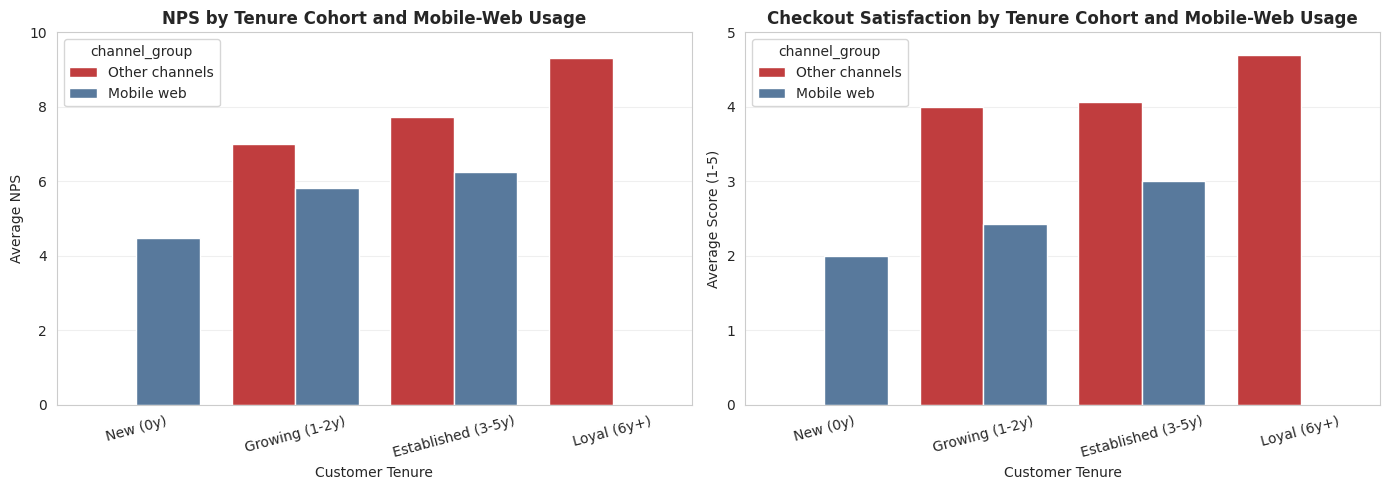

Channel mix is strongly associated with tenure cohort (chi-square p-value = 1.38e-69).
Interpretation: part of the overall mobile gap is mix-driven, so dashboard cuts should always pair channel with tenure.


In [8]:
# Break down the mobile-web claim by tenure cohort
cohort_rows = []
for cohort, sub in df.groupby('tenure_cohort', observed=False):
    mobile = sub[sub['is_mobile_web']]
    other = sub[~sub['is_mobile_web']]

    row = {
        'tenure_cohort': cohort,
        'mobile_web_n': len(mobile),
        'other_channels_n': len(other),
        'mobile_web_nps': round(mobile['nps_score'].mean(), 3) if len(mobile) else np.nan,
        'other_channels_nps': round(other['nps_score'].mean(), 3) if len(other) else np.nan,
        'nps_gap_mobile_minus_other': round(mobile['nps_score'].mean() - other['nps_score'].mean(), 3) if len(mobile) and len(other) else np.nan,
        'mobile_web_checkout': round(mobile['checkout_satisfaction'].mean(), 3) if len(mobile) else np.nan,
        'other_channels_checkout': round(other['checkout_satisfaction'].mean(), 3) if len(other) else np.nan,
        'checkout_gap_mobile_minus_other': round(mobile['checkout_satisfaction'].mean() - other['checkout_satisfaction'].mean(), 3) if len(mobile) and len(other) else np.nan,
    }

    if len(mobile) > 1 and len(other) > 1:
        row['nps_p_value'] = stats.ttest_ind(mobile['nps_score'], other['nps_score'], equal_var=False).pvalue
        row['checkout_p_value'] = stats.ttest_ind(mobile['checkout_satisfaction'], other['checkout_satisfaction'], equal_var=False).pvalue
    else:
        row['nps_p_value'] = np.nan
        row['checkout_p_value'] = np.nan

    cohort_rows.append(row)

cohort_mobile = pd.DataFrame(cohort_rows)
display(cohort_mobile)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = df.copy()
plot_df['channel_group'] = np.where(plot_df['is_mobile_web'], 'Mobile web', 'Other channels')

sns.barplot(data=plot_df, x='tenure_cohort', y='nps_score', hue='channel_group', errorbar=None, palette=['#d62728', '#4c78a8'], ax=axes[0])
axes[0].set_title('NPS by Tenure Cohort and Mobile-Web Usage', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Customer Tenure')
axes[0].set_ylabel('Average NPS')
axes[0].set_ylim(0, 10)
axes[0].tick_params(axis='x', rotation=15)

sns.barplot(data=plot_df, x='tenure_cohort', y='checkout_satisfaction', hue='channel_group', errorbar=None, palette=['#d62728', '#4c78a8'], ax=axes[1])
axes[1].set_title('Checkout Satisfaction by Tenure Cohort and Mobile-Web Usage', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Customer Tenure')
axes[1].set_ylabel('Average Score (1-5)')
axes[1].set_ylim(0, 5)
axes[1].tick_params(axis='x', rotation=15)

for ax in axes:
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

channel_tenure = pd.crosstab(df['channel_preference'], df['tenure_cohort'])
chi2, p_value, dof, expected = stats.chi2_contingency(channel_tenure)
print(f'Channel mix is strongly associated with tenure cohort (chi-square p-value = {p_value:.2e}).')
print('Interpretation: part of the overall mobile gap is mix-driven, so dashboard cuts should always pair channel with tenure.')

## 5. Key Drivers of NPS

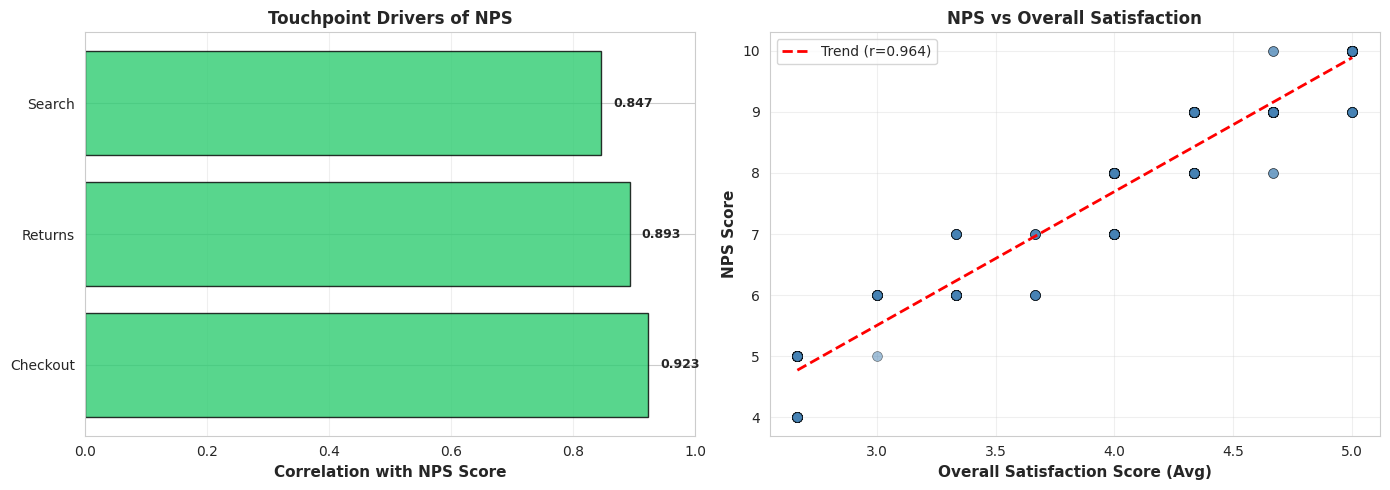

Touchpoint correlations with NPS:
checkout_satisfaction    0.923
returns_satisfaction     0.893
search_satisfaction      0.847
Name: nps_score, dtype: float64

Overall satisfaction ↔ NPS correlation: 0.964


In [9]:
# Correlation analysis: what moves with high NPS?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Satisfaction metrics correlation with NPS
satisfaction_cols = ['checkout_satisfaction', 'search_satisfaction', 'returns_satisfaction']
correlations = df[satisfaction_cols + ['nps_score']].corr()['nps_score'][:-1].sort_values(ascending=False)
label_map = {
    'checkout_satisfaction': 'Checkout',
    'search_satisfaction': 'Search',
    'returns_satisfaction': 'Returns'
}

colors = ['#2ecc71' if x > 0.5 else '#f39c12' for x in correlations.values]
axes[0].barh(range(len(correlations)), correlations.values, color=colors, edgecolor='black', alpha=0.8)
axes[0].set_yticks(range(len(correlations)))
axes[0].set_yticklabels([label_map[col] for col in correlations.index])
axes[0].set_xlabel('Correlation with NPS Score', fontsize=11, fontweight='bold')
axes[0].set_title('Touchpoint Drivers of NPS', fontsize=12, fontweight='bold')
axes[0].set_xlim(0, 1)
axes[0].grid(axis='x', alpha=0.3)

for i, v in enumerate(correlations.values):
    axes[0].text(v + 0.02, i, f"{v:.3f}", va='center', fontweight='bold', fontsize=9)

# NPS vs overall satisfaction (scatter)
axes[1].scatter(df['overall_satisfaction'], df['nps_score'], alpha=0.5, s=50, color='steelblue', edgecolor='black', linewidth=0.5)
axes[1].set_xlabel('Overall Satisfaction Score (Avg)', fontsize=11, fontweight='bold')
axes[1].set_ylabel('NPS Score', fontsize=11, fontweight='bold')
axes[1].set_title('NPS vs Overall Satisfaction', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

# Add trend line
z = np.polyfit(df['overall_satisfaction'], df['nps_score'], 1)
p = np.poly1d(z)
axes[1].plot(
    df['overall_satisfaction'].sort_values(),
    p(df['overall_satisfaction'].sort_values()),
    'r--', linewidth=2,
    label=f"Trend (r={df[['overall_satisfaction', 'nps_score']].corr().iloc[0, 1]:.3f})"
)
axes[1].legend()

plt.tight_layout()
plt.show()

print('Touchpoint correlations with NPS:')
print(correlations.round(3))
print(f"\nOverall satisfaction ↔ NPS correlation: {df[['overall_satisfaction', 'nps_score']].corr().iloc[0, 1]:.3f}")

In [10]:
# Detractor vs Promoter analysis: what differentiates them?
promoters = df[df['nps_segment'] == 'Promoter (9-10)']
detractors = df[df['nps_segment'] == 'Detractor (0-6)']

comparison = pd.DataFrame({
    'Promoters': [
        promoters['checkout_satisfaction'].mean(),
        promoters['search_satisfaction'].mean(),
        promoters['returns_satisfaction'].mean(),
        promoters['overall_satisfaction'].mean(),
        promoters['avg_order_value'].mean(),
        promoters['customer_tenure'].mean(),
        (promoters['channel_preference'] == 'mobile').mean() * 100,
    ],
    'Detractors': [
        detractors['checkout_satisfaction'].mean(),
        detractors['search_satisfaction'].mean(),
        detractors['returns_satisfaction'].mean(),
        detractors['overall_satisfaction'].mean(),
        detractors['avg_order_value'].mean(),
        detractors['customer_tenure'].mean(),
        (detractors['channel_preference'] == 'mobile').mean() * 100,
    ]
}, index=[
    'Checkout Satisfaction', 'Search Satisfaction', 'Returns Satisfaction',
    'Overall Satisfaction', 'Avg Order Value ($)', 'Avg Tenure (years)', 'Mobile Web Users (%)'
]).round(2)
comparison['Gap (Promoter - Detractor)'] = (comparison['Promoters'] - comparison['Detractors']).round(2)

print('Promoters vs Detractors Profile:')
display(comparison)
print(f'Promoters Count: {len(promoters)} ({len(promoters)/len(df)*100:.1f}%)')
print(f'Detractors Count: {len(detractors)} ({len(detractors)/len(df)*100:.1f}%)')

Promoters vs Detractors Profile:


,Promoters,Detractors,Gap (Promoter - Detractor)
Checkout Satisfaction,4.70,2.24,2.46
Search Satisfaction,4.57,3.10,1.47
Returns Satisfaction,4.86,3.39,1.47
Overall Satisfaction,4.71,2.91,1.80
Avg Order Value ($),343.40,100.60,242.80
Avg Tenure (years),8.04,0.87,7.17
Mobile Web Users (%),0.00,100.00,-100.00


Promoters Count: 141 (40.1%)
Detractors Count: 94 (26.7%)


## 6. Heatmap: NPS & Satisfaction by Segment

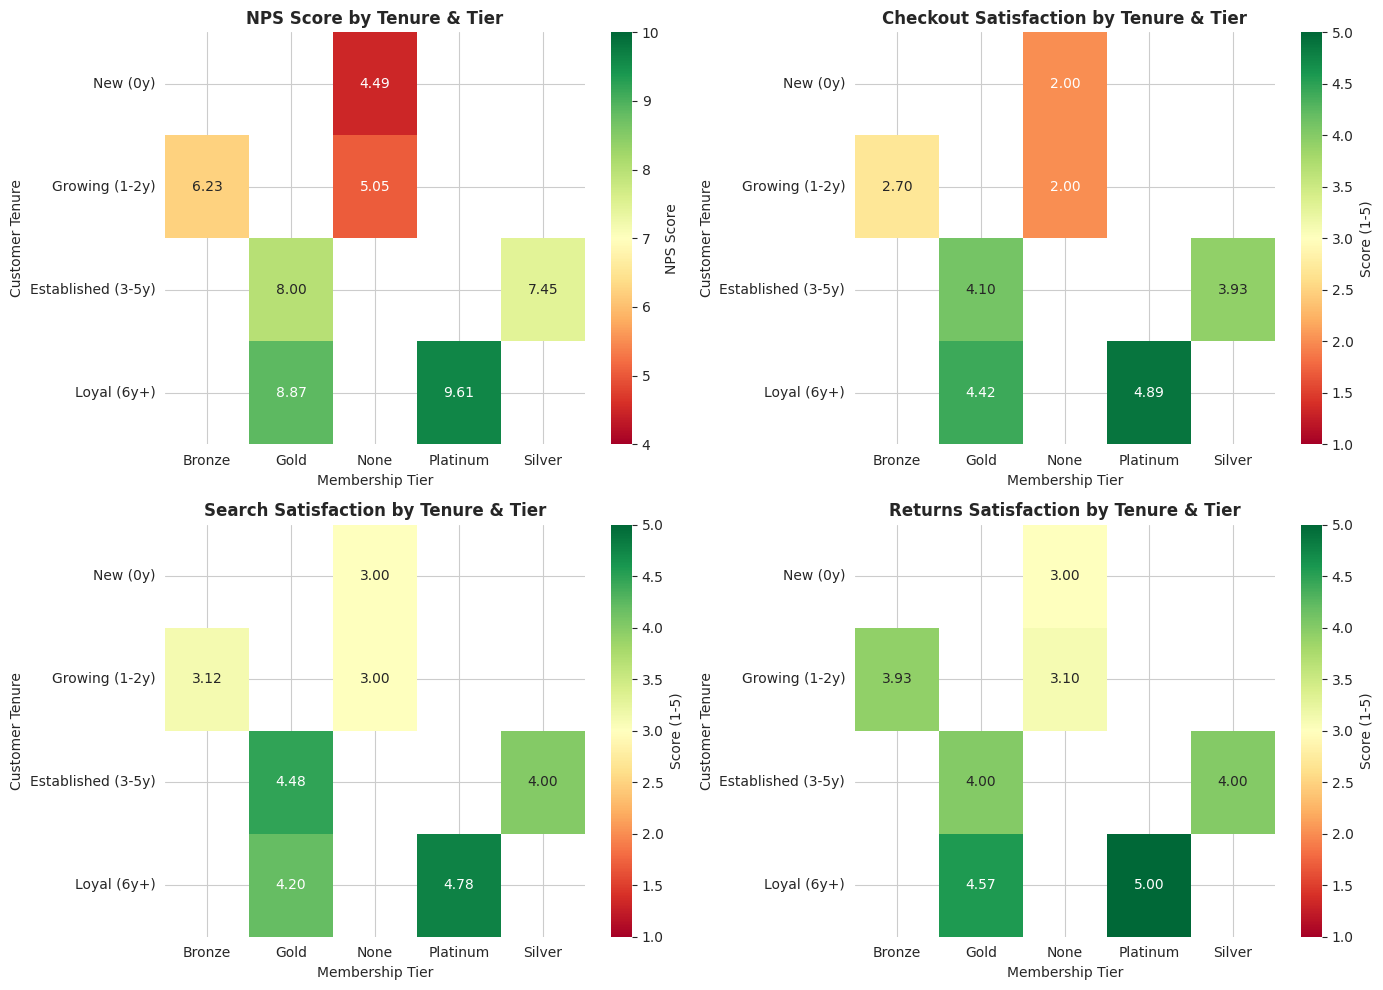

In [11]:
# Create segment-level heatmap of satisfaction metrics
segment_metrics = df.pivot_table(
    values=['nps_score', 'checkout_satisfaction', 'search_satisfaction', 'returns_satisfaction'],
    index='tenure_cohort',
    columns='membership_tier',
    aggfunc='mean'
)

# Create separate heatmaps for clarity
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# NPS heatmap
nps_pivot = df.pivot_table(values='nps_score', index='tenure_cohort', columns='membership_tier', aggfunc='mean')
sns.heatmap(nps_pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=4, vmax=10, ax=axes[0, 0], cbar_kws={'label': 'NPS Score'})
axes[0, 0].set_title('NPS Score by Tenure & Tier', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Membership Tier')
axes[0, 0].set_ylabel('Customer Tenure')

# Checkout satisfaction
checkout_pivot = df.pivot_table(values='checkout_satisfaction', index='tenure_cohort', columns='membership_tier', aggfunc='mean')
sns.heatmap(checkout_pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=1, vmax=5, ax=axes[0, 1], cbar_kws={'label': 'Score (1-5)'})
axes[0, 1].set_title('Checkout Satisfaction by Tenure & Tier', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Membership Tier')
axes[0, 1].set_ylabel('Customer Tenure')

# Search satisfaction
search_pivot = df.pivot_table(values='search_satisfaction', index='tenure_cohort', columns='membership_tier', aggfunc='mean')
sns.heatmap(search_pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=1, vmax=5, ax=axes[1, 0], cbar_kws={'label': 'Score (1-5)'})
axes[1, 0].set_title('Search Satisfaction by Tenure & Tier', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Membership Tier')
axes[1, 0].set_ylabel('Customer Tenure')

# Returns satisfaction
returns_pivot = df.pivot_table(values='returns_satisfaction', index='tenure_cohort', columns='membership_tier', aggfunc='mean')
sns.heatmap(returns_pivot, annot=True, fmt='.2f', cmap='RdYlGn', vmin=1, vmax=5, ax=axes[1, 1], cbar_kws={'label': 'Score (1-5)'})
axes[1, 1].set_title('Returns Satisfaction by Tenure & Tier', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Membership Tier')
axes[1, 1].set_ylabel('Customer Tenure')

plt.tight_layout()
plt.show()

## 7. Dashboard-ready Summary

In [12]:
# Compact tables for a stakeholder dashboard
overall_nps = ((df['nps_score'] >= 9).mean() - (df['nps_score'] <= 6).mean()) * 100
metric_table = pd.DataFrame([
    {'metric': 'Overall NPS', 'value': round(overall_nps, 2)},
    {'metric': 'Mean NPS score', 'value': round(df['nps_score'].mean(), 2)},
    {'metric': 'Promoter share (%)', 'value': round((df['nps_score'] >= 9).mean() * 100, 2)},
    {'metric': 'Detractor share (%)', 'value': round((df['nps_score'] <= 6).mean() * 100, 2)},
    {'metric': 'Checkout ↔ NPS correlation', 'value': round(df[['checkout_satisfaction', 'nps_score']].corr().iloc[0, 1], 3)},
    {'metric': 'Overall satisfaction ↔ NPS correlation', 'value': round(df[['overall_satisfaction', 'nps_score']].corr().iloc[0, 1], 3)},
    {'metric': 'Mobile web checkout gap vs others', 'value': round(df.loc[df['is_mobile_web'], 'checkout_satisfaction'].mean() - df.loc[~df['is_mobile_web'], 'checkout_satisfaction'].mean(), 3)},
    {'metric': 'Mobile web NPS gap vs others', 'value': round(df.loc[df['is_mobile_web'], 'nps_score'].mean() - df.loc[~df['is_mobile_web'], 'nps_score'].mean(), 3)},
])

dashboard_table = cohort_mobile[['tenure_cohort', 'mobile_web_n', 'other_channels_n', 'mobile_web_nps', 'other_channels_nps', 'mobile_web_checkout', 'other_channels_checkout']]

print('Top-line metrics:')
display(metric_table)
print('Mobile-web by tenure cohort (recommended dashboard table):')
display(dashboard_table)

Top-line metrics:


,metric,value
0,Overall NPS,13.350
1,Mean NPS score,7.700
2,Promoter share (%),40.060
3,Detractor share (%),26.700
4,Checkout ↔ NPS correlation,0.923
5,Overall satisfaction ↔ NPS correlation,0.964
6,Mobile web checkout gap vs others,-2.122
7,Mobile web NPS gap vs others,-3.276


Mobile-web by tenure cohort (recommended dashboard table):


,tenure_cohort,mobile_web_n,other_channels_n,mobile_web_nps,other_channels_nps,mobile_web_checkout,other_channels_checkout
0,New (0y),35,0,4.486,NaN,2.000,NaN
1,Growing (1-2y),62,2,5.806,7.000,2.419,4.000
2,Established (3-5y),8,96,6.250,7.729,3.000,4.062
3,Loyal (6y+),0,149,NaN,9.309,NaN,4.698


## Key Findings

1. **Satisfaction is the clearest NPS lever**: overall satisfaction correlates **0.964** with NPS; among touchpoints, **checkout** is the strongest single driver at **0.923**, ahead of returns (**0.893**) and search (**0.847**).
2. **The mobile issue is mobile web, not app**: mobile web averages **5.40 NPS** and **2.32/5 checkout satisfaction** versus **8.68 NPS** and **4.45/5** for all other channels (gaps **-3.28 NPS** and **-2.12 checkout**; Welch t-tests **p=2.42e-79** and **p=2.26e-95**). App users are much healthier at **8.39 NPS** and **4.00/5 checkout satisfaction**.
3. **Tenure explains part of the mobile gap, but not all of it**: **92.4%** of mobile-web respondents are **New or Growing** customers, while **60.3%** of non-mobile-web respondents are **Loyal** (channel × tenure chi-square **p=1.38e-69**). Within the Established cohort, mobile-web users still trail at **6.25 vs 7.73 NPS** and **3.00 vs 4.06 checkout satisfaction** (gaps **-1.48** and **-1.06**; **p=2.15e-05** and **p=7.09e-64**).
4. **Loyalty and tenure amplify NPS**: average NPS rises from **4.49** for New customers to **9.31** for Loyal customers, and from **4.70** for non-members to **9.61** for Platinum members.
5. **Open text supports the quant story**: **70** improvement comments mention mobile/app/checkout friction terms such as crashes, slow performance, or checkout issues.

## Recommended Actions

- Split dashboard reporting into **mobile web** and **app**; combining them hides that app performs near desktop while mobile web is the clear drag.
- Prioritize **mobile-web checkout fixes** for New, Growing, and Established customers; use checkout satisfaction as the leading KPI because it has the strongest touchpoint correlation with NPS.
- Pair the channel view with a **tenure cohort filter** so leadership can separate onboarding mix effects from true channel UX issues.

## Next Analysis Steps

- Quantify how much of the mobile-web NPS gap is explained by tenure and membership mix in a multivariate model.
- Add a date trend cut if leadership wants an early-warning monitor for whether checkout fixes are lifting mobile-web NPS over time.